In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

In [27]:
#data=pd.read_excel("700_data_with_values2.xlsx")
data=pd.read_excel("Rectum_ML_Final_Labels.xlsx")

In [28]:
data["BASELINE_MRI_N_STAGE_OLD"]=data["BASELINE_MRI_N_STAGE_OLD"].fillna(0.0)

In [29]:
data.shape

(902, 40)

In [30]:
features = data.drop(columns=["RECURRENCE",'REG_NO','Date_of_Registration','DATE_LAST_FOLLOW_UP']).columns
x = data[features]
y = data['RECURRENCE']
selector = SelectKBest(score_func=f_classif, k=5)
x_new = selector.fit_transform(x, y)
#selected_features = x.columns[selector.get_support()].tolist()
selected_features=['BASELINE_MRI_T_STAGE','BASELINE_MRI_N_STAGE','UPFRONT_METASTATIC']
#selected_features=list(importances.head(35).index)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [27 32] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [31]:
data.columns

Index(['REG_NO', 'Date_of_Registration', 'RECURRENCE', 'AGE', 'GENDER', 'ECOG',
       'FAMILY_HISTORY', 'PREVIOUS_MALIGNANCY', 'PREVIOUS_COLORECTAL_SURGERY',
       'ASA', 'PRIMARY_EMERGENCY_VS_ELECTIVE', 'BASELINE_MRI_T_STAGE',
       'BASELINE_MRI_N_STAGE', 'UPFRONT_METASTATIC', 'HPR_T_STAGE',
       'HPR_N_STAGE', 'HPR_EMVI', 'HPR_LVI', 'HPR_CRM_INVOLVED', 'HPR_PNI',
       'NEOADJUVANT_TYPE', 'BASELINE_MRI_CRM', 'BASELINE_EMVI',
       'METASTATIC_SITE', 'HISTOLOGY', 'SIGNET_RING', 'MUCINOUS', 'CEA',
       'NEOADJUVANT_TREATMENT', 'ADJUVANT_CHEMO', 'INTENT',
       'COLONOSCOPY_COMPLETE', 'COLONOSCOPY_POLYPS_OTHER', 'BASELINE_PET',
       'BASELINE_MRI_N_STAGE_OLD', 'BASELINE_MRI_AVAILABLE', 'SITE',
       'TUMOR_OBSTRUCTION', 'TME_TYPE', 'DATE_LAST_FOLLOW_UP'],
      dtype='object')

In [32]:
selected_features

['BASELINE_MRI_T_STAGE', 'BASELINE_MRI_N_STAGE', 'UPFRONT_METASTATIC']

In [33]:
import pandas as pd
correlation = data.corr(numeric_only=True)['RECURRENCE'].abs().sort_values(ascending=False)
print(correlation)


RECURRENCE                       1.000000
ADJUVANT_CHEMO                   0.232507
HPR_N_STAGE                      0.198942
HPR_PNI                          0.183226
SIGNET_RING                      0.156200
HPR_CRM_INVOLVED                 0.143469
HPR_EMVI                         0.139240
HPR_T_STAGE                      0.135872
HPR_LVI                          0.127709
TUMOR_OBSTRUCTION                0.125296
HISTOLOGY                        0.117211
AGE                              0.117018
TME_TYPE                         0.104685
BASELINE_MRI_CRM                 0.071926
SITE                             0.066301
NEOADJUVANT_TREATMENT            0.061939
COLONOSCOPY_COMPLETE             0.060749
BASELINE_EMVI                    0.052772
BASELINE_MRI_T_STAGE             0.049407
NEOADJUVANT_TYPE                 0.039528
COLONOSCOPY_POLYPS_OTHER         0.035939
MUCINOUS                         0.035341
PRIMARY_EMERGENCY_VS_ELECTIVE    0.030819
PREVIOUS_MALIGNANCY              0

In [34]:
selected_features

['BASELINE_MRI_T_STAGE', 'BASELINE_MRI_N_STAGE', 'UPFRONT_METASTATIC']

In [35]:
def logistic_regression(features,target='RECURRENCE'):
    x = data[features]
    y = data[target]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y,random_state=42)
    sm = SMOTE(random_state=42,k_neighbors=3)
    x_res, y_res = sm.fit_resample(x_train, y_train)
    scaler = StandardScaler()
    x_res = scaler.fit_transform(x_res)
    x_test = scaler.transform(x_test)
    lr_model = GridSearchCV(LogisticRegression(random_state=42, max_iter=3000),{'C':[0.01,0.1,1.0,10],'solver':['liblinear']},cv=5,scoring='roc_auc',n_jobs=-1)
    lr_model.fit(x_res, y_res)
    predictions = lr_model.predict(x_test)
    probas = lr_model.predict_proba(x_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test,probas)
    accuracy=accuracy_score(y_test, predictions)
    precision=precision_score(y_test, predictions)  
    f_score=f1_score(y_test, predictions)
    return [accuracy,precision,sensitivity,specificity,f_score,auc]

    

In [36]:
def SVM(features,target='RECURRENCE'):
    x = data[features]
    y = data[target]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)
    sm = SMOTE(random_state=42,k_neighbors=3)
    x_res, y_res = sm.fit_resample(x_train, y_train)
    scaler = StandardScaler()
    x_res = scaler.fit_transform(x_res)
    x_test = scaler.transform(x_test)
    svmodel = GridSearchCV(SVC(probability=True, random_state=42), {'C': [0.1, 1, 3], 'gamma': [0.01, 0.1, 'scale'], 'kernel': ['rbf']}, cv=5, scoring='roc_auc', n_jobs=-1)
    svmodel.fit(x_res, y_res)
    predictions = svmodel.predict(x_test)
    probas = svmodel.predict_proba(x_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test,probas)
    accuracy=accuracy_score(y_test, predictions)
    precision=precision_score(y_test, predictions)
    f_score=f1_score(y_test, predictions)
    return [accuracy,precision,sensitivity,specificity,f_score,auc]

In [37]:
def rf(features,target='RECURRENCE'):
    x = data[features]
    y = data[target]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y,random_state=42)
    sm = SMOTE(random_state=42,k_neighbors=3)
    x_res, y_res = sm.fit_resample(x_train, y_train)
    scaler = StandardScaler()
    x_res = scaler.fit_transform(x_res)
    x_test = scaler.transform(x_test)
    rfmodel = GridSearchCV(RandomForestClassifier(random_state=42), {'n_estimators': [200, 300], 'max_depth': [8, 12], 'min_samples_split': [2, 4]}, cv=5, scoring='roc_auc', n_jobs=-1)
    rfmodel.fit(x_res, y_res)
    predictions = rfmodel.predict(x_test)
    probas = rfmodel.predict_proba(x_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test,probas)
    accuracy=accuracy_score(y_test, predictions)
    precision=precision_score(y_test, predictions)
    f_score= f1_score(y_test, predictions)
    return [accuracy,precision,sensitivity,specificity,f_score,auc]
    

In [38]:
def xgb(features,target='RECURRENCE'):
    x = data[features]
    y = data[target]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)
    sm = SMOTE(random_state=42,k_neighbors=3)
    x_res, y_res = sm.fit_resample(x_train, y_train)
    scaler = StandardScaler()
    x_res = scaler.fit_transform(x_res)
    x_test = scaler.transform(x_test)
    xgb_params = {'n_estimators': [100, 200],'learning_rate': [0.01, 0.05, 0.1],'max_depth': [3, 5, 7],'subsample': [0.7, 0.9],'colsample_bytree': [0.7, 0.9]}
    xgmodel = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),xgb_params, cv=5,scoring='roc_auc',n_jobs=-1)
    #xgmodel = XGBClassifier(n_estimators=200, learning_rate=0.03, max_depth=5, subsample=0.9, colsample_bytree=0.9, use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgmodel.fit(x_res, y_res)
    predictions = xgmodel.predict(x_test)
    probas = xgmodel.predict_proba(x_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test,probas)
    accuracy=accuracy_score(y_test, predictions)
    precision=precision_score(y_test, predictions)
    f_score= f1_score(y_test, predictions)
    return [accuracy,precision,sensitivity,specificity,f_score,auc]
    

In [39]:
#features=['BASELINE_MRI_T_STAGE','BASELINE_MRI_N_STAGE','UPFRONT_METASTATIC']


In [40]:
lr_metrics=logistic_regression(selected_features)

In [41]:
svm_metrics=SVM(selected_features)

In [42]:
rf_metrics=rf(selected_features)

In [43]:
xg_metrics=xgb(selected_features)

C:\Users\Lenovo\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:01:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [44]:
lr_metrics

[0.6132596685082873, 0.25, 0.375, 0.6808510638297872, 0.3, 0.5474290780141844]

In [45]:
svm_metrics

[0.4419889502762431,
 0.22522522522522523,
 0.625,
 0.3900709219858156,
 0.33112582781456956,
 0.5908687943262412]

In [46]:
rf_metrics#accuracy,precision,sensitivity,specificity,f_score,auc

[0.46408839779005523,
 0.2336448598130841,
 0.625,
 0.41843971631205673,
 0.3401360544217687,
 0.5664007092198582]

In [47]:
xg_metrics

[0.46408839779005523,
 0.2336448598130841,
 0.625,
 0.41843971631205673,
 0.3401360544217687,
 0.5773936170212767]

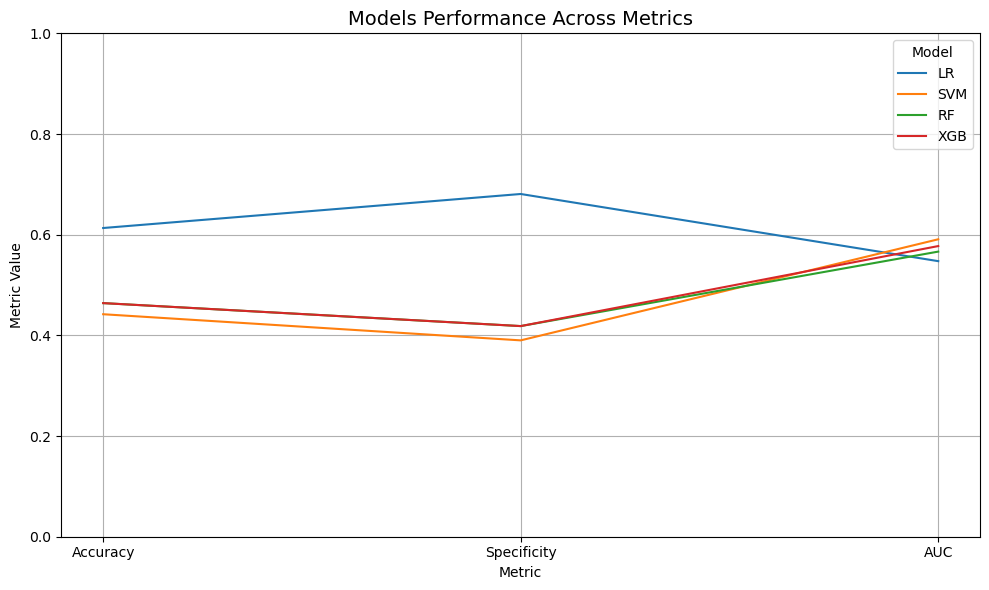

In [48]:
data_to_plot = {
    "Model": ["LR"]*3 + ["SVM"]*3 + ["RF"]*3 + ["XGB"]*3,
    "Metric": ["Accuracy","Specificity", "AUC"] * 4,
    "Value": [
        lr_metrics[0], lr_metrics[3], lr_metrics[5],
        svm_metrics[0], svm_metrics[3], svm_metrics[5],
        rf_metrics[0], rf_metrics[3], rf_metrics[5],
        xg_metrics[0], xg_metrics[3], xg_metrics[5]
    ]
}

df = pd.DataFrame(data_to_plot)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Metric", y="Value", hue="Model", markers=True, dashes=True)
plt.title("Models Performance Across Metrics", fontsize=14)
plt.ylabel("Metric Value")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig("resultplot36f-sens.png")
plt.show()

In [49]:
results={}
results['Logistic Regression']=lr_metrics
results['Support Vector Machine']=svm_metrics
results['Random Forest']=rf_metrics
results['Gradient Boosting']=xg_metrics
results_df_3features_tnm = pd.DataFrame.from_dict(results, orient="index",columns=["Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-score", "AUC"])



In [51]:
#results_df_35features_tnm#35

In [ ]:
results_df_4features_tnm#30

In [ ]:
results_df_3features_tnm#3featurestnm

In [ ]:
results_df_3features_tnm#3featurestnm

In [ ]:
results_df2#35features

In [ ]:
results_df3#36features

In [ ]:
results_df4#30features

In [ ]:
results_df3.to_excel('results_with_36_features.xlsx', index=False)

In [ ]:
results_df4.to_excel('results_with_3_features.xlsx', index=False)

In [ ]:
results_df2.to_excel('results_with_35_features.xlsx', index=False)

In [ ]:
results_df5

In [ ]:
results_df5#36

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.countplot(x=data["RECURRENCE"])
plt.title("Class Distribution of Recurrence")
plt.xlabel("Recurrence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Total number of records
total_records = len(data["RECURRENCE"])

# Plotting
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=data["RECURRENCE"])
plt.title("Class Distribution of Recurrence")
plt.xlabel("Recurrence")
plt.ylabel("Count")

# Add total number of records to the top-right corner inside the plot
# You can adjust `x` and `y` values as needed for better positioning
plt.text(
    x=0.95, 
    y=0.95, 
    s=f'Total: {total_records}', 
    transform=ax.transAxes,  # Use axis coordinates (0 to 1)
    ha='right', 
    va='top', 
    fontsize=10, 
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", edgecolor="gray")
)

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Original value counts
recurrence_counts = data["RECURRENCE"].value_counts()

# Add total as a new category
recurrence_counts["Total"] = len(data["RECURRENCE"])

# Convert to DataFrame for plotting
plot_data = recurrence_counts.reset_index()
plot_data.columns = ["Recurrence", "Count"]

# Plotting
plt.figure(figsize=(8, 8))
ax = sns.barplot(x="Recurrence", y="Count", data=plot_data)

# Title and labels
plt.title("Class Distribution of Recurrence")
#plt.title("Class Distribution of Recurrence (Including Total)")
plt.xlabel("Recurrence")
plt.ylabel("Count")

# Add value labels on top of each bar
for i, row in plot_data.iterrows():
    ax.text(i, row["Count"] + max(plot_data["Count"]) * 0.02,  # Slight offset above bar
            str(row["Count"]), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Total number of records in the "RECURRENCE" column
total_records = len(data["RECURRENCE"])
print(f"Total number of records: {total_records}")

# Plotting
plt.figure(figsize=(6, 4))
sns.countplot(x=data["RECURRENCE"])
plt.title("Class Distribution of Recurrence")
plt.xlabel("Recurrence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
#help(plt)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
X = data.drop(columns=["REG_NO", "Date_of_Registration", "DATE_LAST_FOLLOW_UP", "RECURRENCE"])
y = data["RECURRENCE"]
X = X.fillna(X.median())
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)
#model = RandomForestClassifier(random_state=42)
#model=LogisticRegression(random_state=42, max_iter=3000)
#model=SVC(probability=True, random_state=42)
model=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 30 Features for Recurrence Prediction by XGB")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
#['ADJUVANT_CHEMO','']

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_, X_test, _, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Recurrence", "Recurrence"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
# Plot ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
# Drop identifier/date columns
df_corr = data.drop(columns=["REG_NO", "Date_of_Registration", "DATE_LAST_FOLLOW_UP"])
# Compute and plot correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', square=True, cbar_kws={"shrink": .5})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
results={}
results['Logistic Regression']=[lr_metrics[0],lr_metrics[3],lr_metrics[5]]
results['Support Vector Machine']=[svm_metrics[0],svm_metrics[3],svm_metrics[5]]
results['Random Forest']=[rf_metrics[0],rf_metrics[3],rf_metrics[5]]
results['Gradient Boosting']=[xg_metrics[0],xg_metrics[3],xg_metrics[5]]
results_df_3features_tnm= pd.DataFrame.from_dict(results, orient="index",columns=["Accuracy",   "Specificity",  "AUC"])



In [ ]:
results_df_35features_tnm

In [ ]:
results_df_4features_tnm

In [ ]:
results_df_3features_tnm

In [ ]:
pd.to_csv(results_df5,index=True)

In [ ]:
dataresult=pd.DataFrame(results_df5,columns=['Accuracy','Recall',"Specificity",'AUC'])

In [ ]:
import seaborn as sns

In [ ]:
help(sns)

In [ ]:
dataresult

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=dataresult, y="RECURRENCE", data=dataresult, estimator=sum, ci=None)
plt.title("Total Bill by Day")
plt.show()

In [ ]:
data